In [55]:
import os
import numpy as np
import pandas as pd
import pickle as pkl
import h5py
import nexusformat.nexus as nx
import matplotlib.pyplot as plt
path = '/home/mina-joojoo/Desktop/tool_wearing/h5_files/'

In [56]:
info = pd.read_csv(os.path.join(path, 'filelist.csv'))
info_df = pd.DataFrame(info, columns = info.keys())
info_df.head()
# info_df.isnull().sum()

,filename,machine,tool,run,cumulated_tool_contact_time,wear
0,M1T1R1C11VB3.h5,1,1,1,11,3
1,M1T1R2C15VB3.h5,1,1,2,15,3
2,M1T1R3C19VB4.h5,1,1,3,19,4
3,M1T1R4C23VB5.h5,1,1,4,23,5
4,M1T1R5C27VB6.h5,1,1,5,27,6


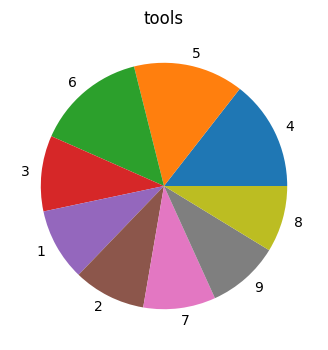

In [58]:
plt.figure(figsize=(4, 4))
plt.pie(info_df['tool'].value_counts(), labels = info_df['tool'].value_counts().index)
plt.title('tools')
plt.show()

**EXP:"M2T4R910C5086VB147.h5":**
Machine= 2
Tool= 4
Run= 910
Time= 5086
wear= 147

In [6]:
def print_h5_tree(name, obj, indent=0):
    """Print the HDF5 tree structure with the number of values for datasets."""
    if isinstance(obj, h5py.Dataset):
        print("    " * indent + f"── {name} ({type(obj).__name__}, shape: {obj.shape})")
    else:
        print("    " * indent + f"── {name} ({type(obj).__name__})")

    if isinstance(obj, h5py.Group):
        for key in obj.keys():
            print_h5_tree(key, obj[key], indent + 1)

In [7]:
with h5py.File(os.path.join(path, 'M3T9R543C3072VB129.h5'), 'r') as f:
    for key in f.keys():
        print_h5_tree(key, f[key])

── labels (Group)
    ── cumulated_tool_contact_time (Dataset, shape: (1, 1))
    ── machine (Dataset, shape: (1, 1))
    ── run (Dataset, shape: (1, 1))
    ── tool (Dataset, shape: (1, 1))
    ── wear (Dataset, shape: (1, 1))
── signals_machine (Group)
    ── force_axis_x (Dataset, shape: (1, 2224))
    ── force_axis_y (Dataset, shape: (1, 2224))
    ── force_axis_z (Dataset, shape: (1, 2224))
    ── position_control_deviation_axis_x (Dataset, shape: (1, 2224))
    ── position_control_deviation_axis_y (Dataset, shape: (1, 2224))
    ── time_machine (Dataset, shape: (1, 2224))
    ── tool_position_x (Dataset, shape: (1, 2224))
    ── tool_position_y (Dataset, shape: (1, 2224))
    ── tool_position_z (Dataset, shape: (1, 2224))
    ── torque_spindle (Dataset, shape: (1, 2224))
── signals_sensor (Group)
    ── force_sensor_x (Dataset, shape: (1, 111150))
    ── force_sensor_y (Dataset, shape: (1, 111150))
    ── force_sensor_z (Dataset, shape: (1, 111150))
    ── time_sensor (Dataset, s

In [76]:
import h5py
import matplotlib.pyplot as plt
import os

def plot_single_h5(
    file_path,
    signals_to_plot=None,
    n_cols=2,
    figsize=(15, 10),
    title_fontsize=12,
    line_width=1.5
):

    with h5py.File(file_path, 'r') as f:
        
        labels = {
            'cumulated_tool_contact_time': f['labels/cumulated_tool_contact_time'][0, 0],
            'machine': f['labels/machine'][0, 0],
            'run': f['labels/run'][0, 0],
            'tool': f['labels/tool'][0, 0],
            'wear': f['labels/wear'][0, 0]
        }

    
        if signals_to_plot is None:
    
            signals_to_plot = (
                list(f['signals_machine'].keys()) +
                list(f['signals_sensor'].keys())
            )
        else:
            valid_signals = (
                list(f['signals_machine'].keys()) +
                list(f['signals_sensor'].keys())
            )
            signals_to_plot = [s for s in signals_to_plot if s in valid_signals]
            if not signals_to_plot:
                raise ValueError("No valid signals found in the specified list.")

        # Create subplots
        n_signals = len(signals_to_plot)
        n_rows = (n_signals + n_cols - 1) // n_cols  # Calculate number of rows
        fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize)
        if n_rows == 1:
            axs = [axs]  # Ensure axs is iterable for single row
        axs = [ax for row in axs for ax in row]  # Flatten axs for easy iteration

        # Plot each signal
        for ax_idx, signal in enumerate(signals_to_plot):
            # Determine the group (signals_machine or signals_sensor)
            if signal in f['signals_machine']:
                time = f[f'signals_machine/time_machine'][0, :]
                data = f[f'signals_machine/{signal}'][0, :]
                time_label = 'Time (Machine)'
            else:
                time = f[f'signals_sensor/time_sensor'][0, :]
                data = f[f'signals_sensor/{signal}'][0, :]
                time_label = 'Time (Sensor)'

            # Plot the signal
            axs[ax_idx].plot(time, data, linewidth=line_width)
            axs[ax_idx].set_title(f"{signal}", fontsize=title_fontsize)
            axs[ax_idx].set_xlabel(time_label)

            # Split y-axis label into a maximum of 2 lines
            y_label = signal.replace('_', ' ').title()  # Replace underscores with spaces and capitalize
            words = y_label.split()
            if len(words) > 2:
                # Split into 2 lines: first half and second half
                mid = len(words) // 2

            axs[ax_idx].grid(True, linestyle='--', alpha=0.7)

        # Hide unused subplots
        for ax in axs[ax_idx + 1:]:
            ax.axis('off')

        # Add a suptitle with metadata
        suptitle = (
            f"Machine: {labels['machine']}, Tool: {labels['tool']}, "
            f"Run: {labels['run']}, Wear: {labels['wear']}, "
            f"Cumulated Contact Time: {labels['cumulated_tool_contact_time']}"
        )
        plt.suptitle(suptitle, y=1.02, fontsize=title_fontsize + 2)

        plt.tight_layout()
        plt.show()
        for i, signal in enumerate(signals_to_plot):

            y = all_signals[signal]

            axs[i].scatter(x_ref, y, s=5, alpha=0.4)
            axs[i].set_title(f"{signal} vs {reference_signal}")
            axs[i].set_xlabel(reference_signal)
            axs[i].set_ylabel(signal)
            axs[i].grid(True)

        # hide empty plots
        for ax in axs[n_signals:]:
            ax.axis('off')

        plt.tight_layout()
        plt.show()


In [ ]:
plot_single_h5(
    path + 'M1T3R145C819VB54.h5',
    signals_to_plot=None,
    n_cols=2,
    figsize=(10, 10),
    title_fontsize=12,
    line_width=1.5
)

In [10]:
# from numpy import ndarray

# def validate_signal(signal, expected_length = 1824): #2224   2206
#     if len(signal) != expected_length:
#         diff = int(expected_length - len(signal))
#         if diff > 10:
#             print(f'Warning! {diff} values are missing')
#         pad_value = np.mean(signal[-1*diff:])
#         padding = np.full(diff, pad_value)
#         return np.concatenate([signal, padding])
#     else:
#         return signal

# def denoise_signal(signal, n_neighbors=1000):
#     from sklearn.neighbors import KNeighborsRegressor
#     x = np.arange(len(signal)).reshape(-1, 1)
#     model = KNeighborsRegressor(
#         n_neighbors=n_neighbors,
#         weights='distance'
#     )
#     model.fit(x, signal)
#     smoothed = model.predict(x)
#     return smoothed


In [46]:
def mag_signal(signals):
    return np.linalg.norm(signals)
    
def load_h5(file):
    with h5py.File(file, 'r') as f:
        signals = {}
        for group in ['signals_machine', 'signals_sensor']:
            try:
                signals['f_axis_tot'] = mag_signal([f[group][f'force_axis_{comp}'] for comp in ['x','y','z']])
            except KeyError:
                try:
                    signals['torque_axis_tot'] = mag_signal([f[group][f'torque_axis_{comp}'] for comp in ['x','y','z']])
                except KeyError:
                    try:
                        signals['force_sensor_tot'] = mag_signal([f[group][f'force_sensor_{comp}'] for comp in ['x','y','z']])
                    except KeyError:
                        continue
                        
            for key in f[group]:
                raw_signal = np.array(f[group][key])
                if raw_signal.ndim > 1:
                    raw_signal = raw_signal.flatten()
                signals[key] = raw_signal[200:-200]
            
        labels = f['labels']
        vb = labels['wear'][0,0].astype(float)
        C = labels['cumulated_tool_contact_time'][0,0].astype(float)
        tool = labels['tool'][0,0].astype(float)
        machine = labels['machine'][0,0].astype(float)
    return signals, vb, C, tool, machine

In [47]:
rename_mapping = {
    'force_axis_x': 'fx',
    'force_axis_y': 'fy',
    'force_axis_z': 'fz',
    'position_control_deviation_axis_x': 'pcx',
    'position_control_deviation_axis_y': 'pcy',
    # 'time_machine': 'time',
    # 'tool_position_x': 'tx',
    # 'tool_position_y': 'ty',
    # 'tool_position_z': 'tz',
    'torque_spindle': 'torque',
    'torque_axis_x' : 'torque_x',
    'torque_axis_y' : 'torque_y',
    'torque_axis_z' : 'torque_z',
    'force_sensor_x' : 'fx_sens',
    'force_sensor_y' : 'fy_sens',
    'force_sensor_z' : 'fz_sens',
    'torque_axis_tot' : 'torq_tot',
    'force_axis_tot' : 'f_axis',
    'force_sensor_tot' : 'f_sens'
}



def extract_time_features(signal, k):
    signal_key = rename_mapping[k]
    return {
        f"{signal_key}_mean": np.mean(signal),
        f"{signal_key}_std": np.std(signal),
        f"{signal_key}_max": np.max(signal),
        f"{signal_key}_min": np.min(signal),
        f"{signal_key}_rms": np.sqrt(np.mean(signal**2)),
        f"{signal_key}_skew": np.mean((signal - np.mean(signal))**3)
    }

In [48]:
# now build the dataset
info_df_lst = []

for f in info_df['filename']:
    signals, VB, C, T, M = load_h5(os.path.join(path, f))
    featured_signals = {
        "VB": VB,
        "C": C,
        "tool": T,
        "machine": M}
    
    for k in signals.keys():
        if k in rename_mapping.keys():
            signal_feature = extract_time_features(signals[k], k)
            featured_signals.update(signal_feature)
            
    info_df_lst.append(featured_signals)

In [54]:
dataset = pd.DataFrame(info_df_lst)
dataset.describe()

,VB,C,tool,machine,torq_tot_mean,torq_tot_std,torq_tot_max,torq_tot_min,torq_tot_rms,torq_tot_skew,...,fy_max,fy_min,fy_rms,fy_skew,fz_mean,fz_std,fz_max,fz_min,fz_rms,fz_skew
count,6418.000000,6418.000000,6418.000000,6418.000000,1856.000000,1856.0,1856.000000,1856.000000,1856.000000,1856.0,...,4562.000000,4562.000000,4562.000000,4.562000e+03,4562.000000,4562.000000,4562.000000,4562.000000,4562.000000,4.562000e+03
mean,81.339981,2124.464475,4.968059,1.987847,221.661477,0.0,221.661477,221.661477,221.661477,0.0,...,253.683889,-776.977839,407.834715,-2.235255e+05,-64.875930,347.320740,990.113700,-1117.891620,556.186859,-3.270757e+06
std,30.149191,1304.602639,2.396248,0.752436,3.328708,0.0,3.328708,3.328708,3.328708,0.0,...,131.206304,656.414993,261.417056,9.973889e+06,346.016510,272.127107,1184.108680,565.818804,96.108770,1.474872e+07
min,3.000000,11.000000,1.000000,1.000000,212.786804,0.0,212.786804,212.786804,212.786804,0.0,...,-82.031250,-2341.796875,64.097275,-8.262330e+07,-581.101440,17.316572,-533.299988,-3574.953369,367.070618,-9.606671e+07
25%,58.000000,1045.250000,3.000000,1.000000,219.343689,0.0,219.343689,219.343689,219.343689,0.0,...,173.000000,-1239.013672,120.062674,-1.134785e+04,-470.480530,23.467924,-403.050003,-1544.435028,478.975281,-5.696668e+06
50%,79.000000,2048.000000,5.000000,2.000000,221.893982,0.0,221.893982,221.893982,221.893982,0.0,...,228.349998,-917.968750,461.578003,5.014717e+03,165.440636,461.539551,1485.454407,-1055.052307,542.611481,-6.857768e+03
75%,100.000000,3053.000000,7.000000,3.000000,223.989231,0.0,223.989231,223.989231,223.989231,0.0,...,312.500000,-43.500000,603.914062,2.903753e+06,220.269325,574.160126,1957.820129,-581.500000,616.635925,-1.882440e+03
max,160.000000,5181.000000,9.000000,3.000000,233.109909,0.0,233.109909,233.109909,233.109909,0.0,...,836.914062,14.600000,1005.733154,1.505806e+07,331.674774,940.730530,3785.176758,-485.100006,970.559509,1.343548e+08


In [50]:
null_counts = dataset.isnull().sum()
print(list(null_counts))

[0, 0, 0, 0, 4562, 4562, 4562, 4562, 4562, 4562, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4562, 4562, 4562, 4562, 4562, 4562, 4562, 4562, 4562, 4562, 4562, 4562, 4562, 4562, 4562, 4562, 4562, 4562, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1856, 1856, 1856, 1856, 1856, 1856, 1856, 1856, 1856, 1856, 1856, 1856, 1856, 1856, 1856, 1856, 1856, 1856]


In [52]:
dataset.to_csv('all_data.csv', index=False)